In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
digits = load_digits()
X = torch.FloatTensor(digits.data).to(device) / 16.0

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 32)
        self.fc21 = nn.Linear(32, 2)
        self.fc22 = nn.Linear(32, 2)
        self.fc3 = nn.Linear(2, 32)
        self.fc4 = nn.Linear(32, 64)
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [4]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [5]:
for epoch in range(100):
    optimizer.zero_grad()
    recon_batch, mu, logvar = model(X)
    loss = loss_function(recon_batch, X, mu, logvar)
    loss.backward()
    optimizer.step()

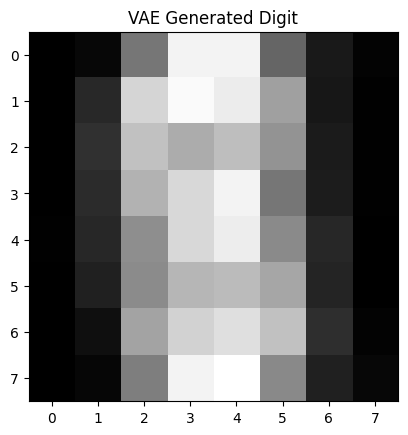

In [6]:
with torch.no_grad():
    sample = torch.randn(1, 2).to(device)
    sample = model.decode(sample).view(8, 8)
plt.imshow(sample.cpu().numpy(), cmap='gray')
plt.title('VAE Generated Digit')
plt.savefig('digits_vae_generated.png')